In [1]:
import os
print("Current working directory:", os.getcwd())
print("Files in current directory:", os.listdir('.'))
os.chdir('C:/Users/Tom/Desktop/east_africa_conflict_analysis/')

Current working directory: c:\Users\Tom\Desktop\east_africa_conflict_analysis\notebooks
Files in current directory: ['exploratory_data_analysis.ipynb', 'explore_model_outputs.ipynb']


In [2]:
# --- 1. Imports ---
from src.data_cleaning import clean_data_pipeline
from src.feature_engineering import feature_engineering_pipeline
from src.modelling import run_gwr_pipeline
import matplotlib.pyplot as plt
import geopandas as gpd

# --- 2. Load your processed GeoDataFrame ---
def run_country_gwr(
    data,
    country_key,
    y_var,
    x_vars,
    feature_keys,
    unit_id_col="GID_2"
):
    """
    Runs feature engineering and GWR for a single country.
    """

    # 1. Feature engineering
    data = feature_engineering_pipeline(
        data=data,
        country_key=country_key,
        feature_keys=feature_keys,
        unit_id_col=unit_id_col
    )

    gdf = data[country_key]["features"].copy()

    print(gdf.columns)

    # 2. Check y_var and x_vars exist
    missing = [col for col in [y_var] + x_vars if col not in gdf.columns]
    if missing:
        raise ValueError(f"Missing required columns in gdf: {missing}")

    # 3. Drop rows with NA in y or any x
    gdf = gdf.dropna(subset=[y_var] + x_vars).copy()

    print(f"\n===== Running GWR for {country_key.upper()} =====")
    print(f"Dependent variable: {y_var}")
    print(f"Predictors: {x_vars}")
    print(f"Feature keys used: {feature_keys}")
    print(f"Remaining observations: {len(gdf)}")

    # --- MINIMAL NEW CODE STARTS HERE ---
    n = len(gdf)
    if n < 20:
        print(f"⚠️ WARNING: Only {n} observations. GWR may be unstable.")

    # Safe bandwidth bounds
    min_bw_predictor_rule = (len(x_vars) + 1) * 5   # at least this many
    bw_min = max(min_bw_predictor_rule, 10)
    bw_max = max(int(n * 0.8), bw_min + 1)          # avoid bw_min >= bw_max

    print(f"Using bandwidth bounds: bw_min={bw_min}, bw_max={bw_max}")
    # --- MINIMAL NEW CODE ENDS HERE ---

    # 4. Run GWR pipeline (pass new bounds)
    gdf_gwr, gwr_results, bw = run_gwr_pipeline(
        gdf,
        y_var=y_var,
        x_vars=x_vars,
        standardize=True,
        kernel='gaussian',
        auto_select_bw=True,
        bw_min=bw_min,      # NEW
        bw_max=bw_max       # NEW
    )

    # 5. Print summary
    print(f"\nSelected bandwidth: {bw}")
    print(gwr_results.summary())

    return gdf_gwr, gwr_results, bw


In [3]:
data = clean_data_pipeline()

# Kenya
gdf_gwr_ken, gwr_results_ken, bw_ken = run_country_gwr(
    data=data,
    country_key="ken",
    y_var="log_conflict_rate",
    x_vars=["log_police_density", "log_hospitals_density", "log_schools_density"],
    feature_keys=["police", "hospitals", "schools"],
    unit_id_col="GID_2"
)

# Ethiopia
gdf_gwr_eth, gwr_results_eth, bw_eth = run_country_gwr(
    data=data,
    country_key="eth",
    y_var="log_conflict_rate",
    x_vars=["log_police_density", "log_hospitals_density", "log_schools_density"],
    feature_keys=["police", "hospitals", "schools"],
    unit_id_col="GID_2"  
)

# South Sudan
gdf_gwr_ssd, gwr_results_ssd, bw_ssd = run_country_gwr(
    data=data,
    country_key="ssd",
    y_var="log_conflict_rate",
    x_vars=["log_police_density", "log_hospitals_density", "log_schools_density"],
    feature_keys=["police", "hospitals", "schools"],
    unit_id_col="GID_2"  
)

# Uganda
gdf_gwr_uga, gwr_results_uga, bw_uga = run_country_gwr(
    data=data,
    country_key="uga",
    y_var="log_conflict_rate",
    x_vars=["log_police_density", "log_hospitals_density", "log_schools_density"],
    feature_keys=["police", "hospitals", "schools"],
    unit_id_col="GID_2"
)


Starting data cleaning pipeline...
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\eth_police.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\eth_hospitals.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\eth_schools.parquet


c:\Users\Tom\anaconda3\envs\gisc412\Lib\site-packages\osmnx\_overpass.py:267: UserWarning: This area is 528 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


Failed to download roads data for Ethiopia: ("Could not convert '125' with type str: tried to convert to int64", 'Conversion failed for column id with type object')
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\ken_police.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\ken_hospitals.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\ken_schools.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\ken_roads.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\ssd_police.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\ssd_hospitals.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\ssd_schools.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\ssd_roads.parquet
Using existing C:\Users\Tom\Desktop\east_africa_conflict_analysis\data\uga_police.parquet
Using existing C:\U

c:\Users\Tom\anaconda3\envs\gisc412\Lib\site-packages\osmnx\_overpass.py:267: UserWarning: This area is 113 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


Failed to download roads data for Uganda: ("Could not convert '19839' with type str: tried to convert to int64", 'Conversion failed for column id with type object')
Replaced 226794771 missing values (-99999.0) with 0 in eth - population
Replaced 100583464 missing values (-99999.0) with 0 in ken - population
Replaced 152824419 missing values (-99999.0) with 0 in ssd - population
Replaced 34422521 missing values (-99999.0) with 0 in uga - population
Data cleaning complete.
Starting feature engineering pipeline for: ken
  - Spatially joining ACLED events to admin units...
  - Spatially joining police to admin units...
  - Spatially joining hospitals to admin units...
  - Spatially joining schools to admin units...
  -> Aggregation complete: conflict_count + feature counts added.
Adding population from raster to admin units...
  - Population raster CRS: EPSG:32637
  - Running zonal statistics (sum of population per unit). This may take a moment...
  -> Population added to features (NaN for

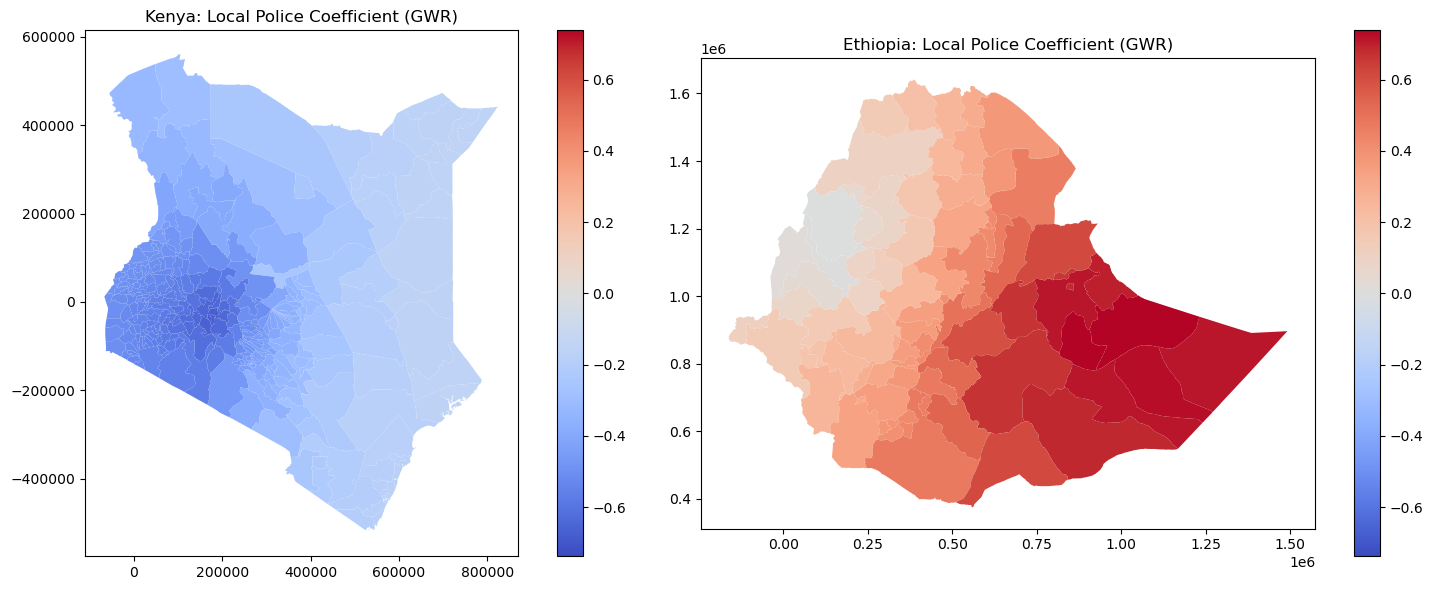

In [4]:
import matplotlib.pyplot as plt

coef_col = 'gwr_log_hospitals_density_coef'

# 1. Compute symmetric scale across BOTH countries
min_val = min(gdf_gwr_ken[coef_col].min(), gdf_gwr_eth[coef_col].min())
max_val = max(gdf_gwr_ken[coef_col].max(), gdf_gwr_eth[coef_col].max())
max_abs = max(abs(min_val), abs(max_val))

# 2. Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Kenya
gdf_gwr_ken.plot(
    column=coef_col,
    cmap='coolwarm',
    vmin=-max_abs,
    vmax=max_abs,
    legend=True,
    ax=axes[0]
)
axes[0].set_title("Kenya: Local Police Coefficient (GWR)")

# Ethiopia
gdf_gwr_eth.plot(
    column=coef_col,
    cmap='coolwarm',
    vmin=-max_abs,
    vmax=max_abs,
    legend=True,
    ax=axes[1]
)
axes[1].set_title("Ethiopia: Local Police Coefficient (GWR)")

plt.tight_layout()
plt.show()


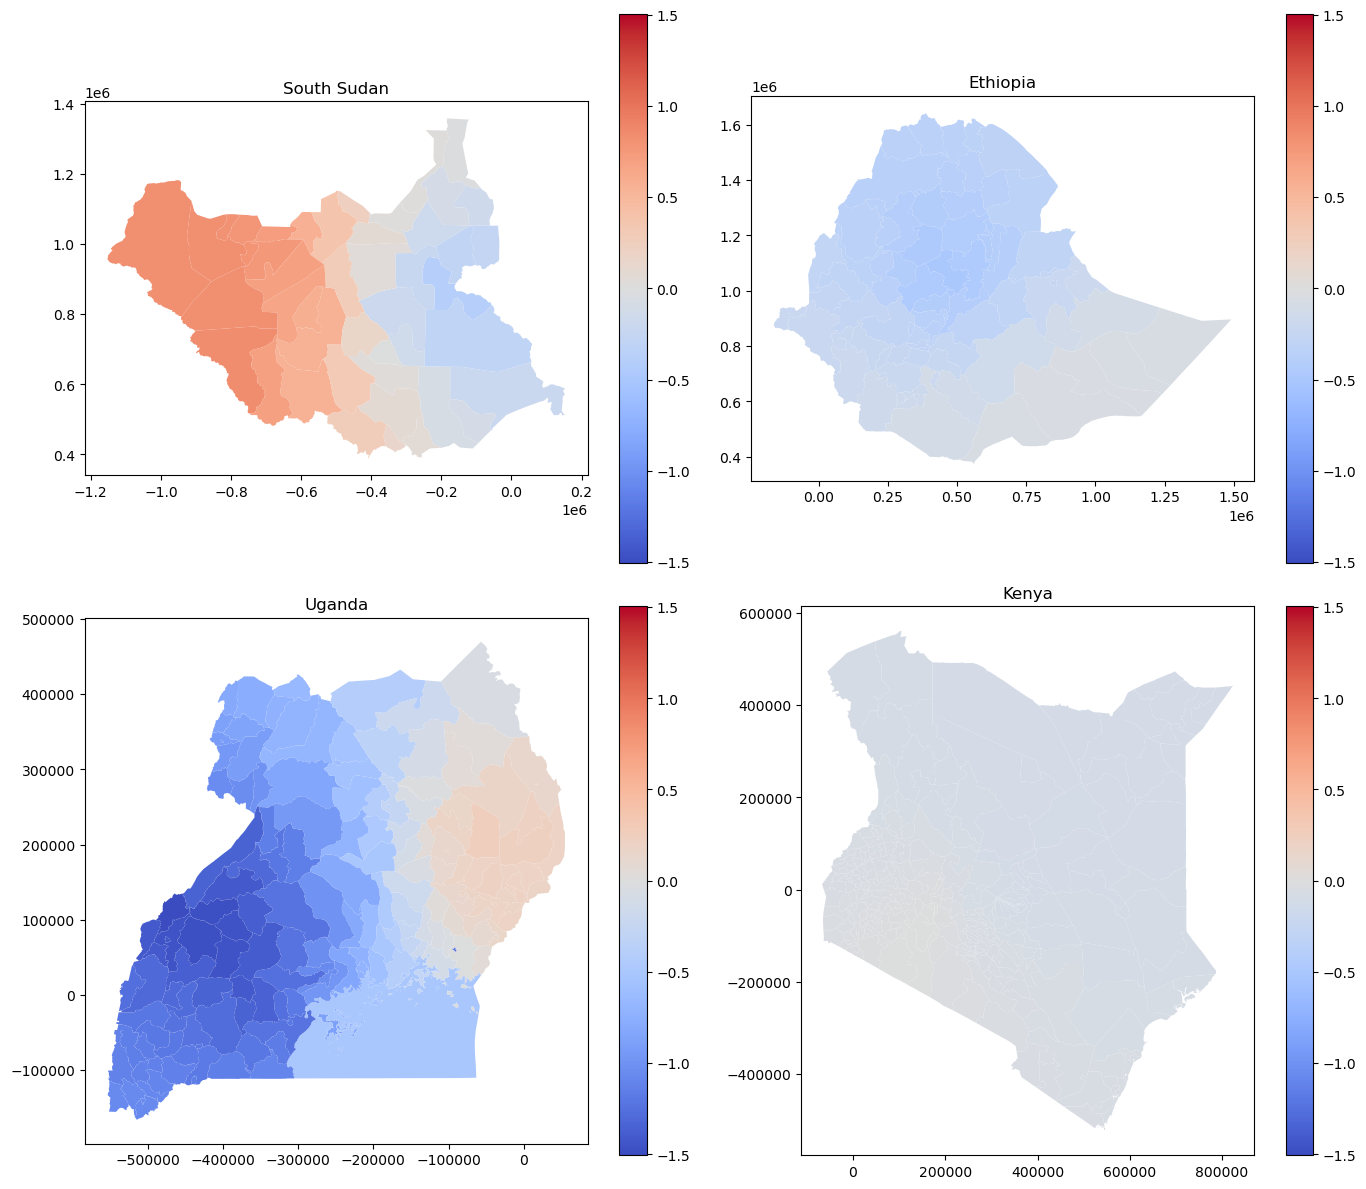

In [5]:

import matplotlib.pyplot as plt
import pandas as pd

coef_col = 'gwr_log_schools_density_coef'  # or any other coefficient column

# 1. Collect all coefficient values across countries
all_vals = pd.concat([
    gdf_gwr_ken[coef_col],
    gdf_gwr_eth[coef_col],
    gdf_gwr_ssd[coef_col],
    gdf_gwr_uga[coef_col]
], axis=0)

# 2. Compute symmetric color bounds
min_val = all_vals.min()
max_val = all_vals.max()
max_abs = max(abs(min_val), abs(max_val))

# 3. Create a 2x2 subplot of countries arranged geographically
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Top-right: Ethiopia
gdf_gwr_eth.plot(
    column=coef_col,
    cmap='coolwarm',
    vmin=-max_abs,
    vmax=max_abs,
    legend=True,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Ethiopia")

# Top-left: South Sudan
gdf_gwr_ssd.plot(
    column=coef_col,
    cmap='coolwarm',
    vmin=-max_abs,
    vmax=max_abs,
    legend=True,
    ax=axes[0, 0]
)
axes[0, 0].set_title("South Sudan")

# Bottom-right: Kenya
gdf_gwr_ken.plot(
    column=coef_col,
    cmap='coolwarm',
    vmin=-max_abs,
    vmax=max_abs,
    legend=True,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Kenya")

# Bottom-left: Uganda
gdf_gwr_uga.plot(
    column=coef_col,
    cmap='coolwarm',
    vmin=-max_abs,
    vmax=max_abs,
    legend=True,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Uganda")

plt.tight_layout()
plt.show()


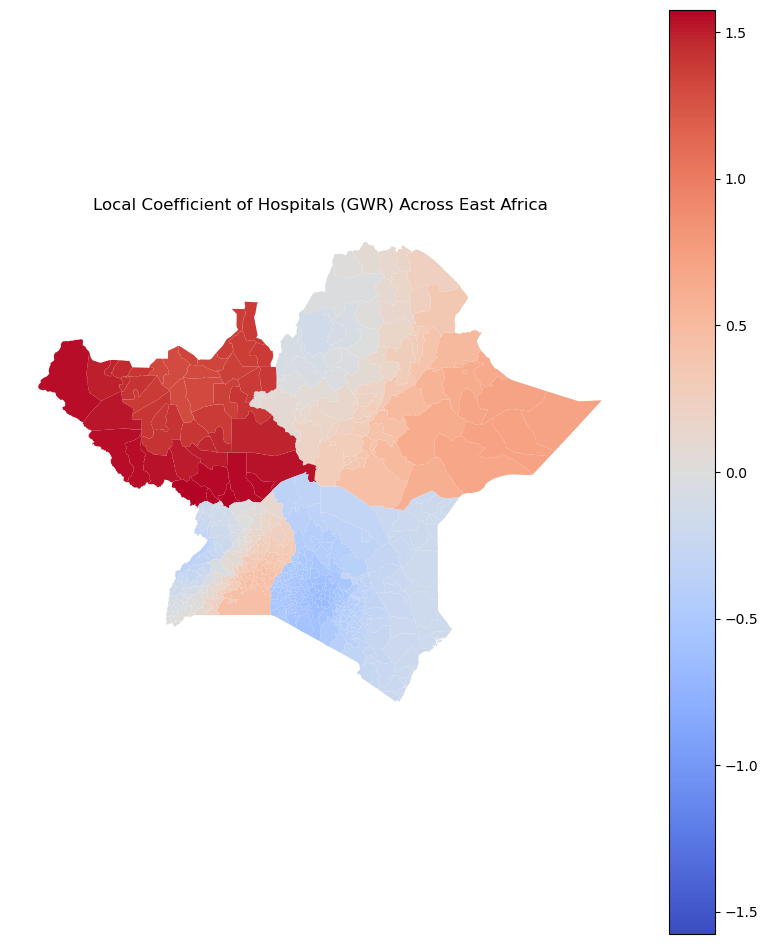

In [12]:
import geopandas as gpd
gdf_all = pd.concat([
    gdf_gwr_eth,
    gdf_gwr_ssd,
    gdf_gwr_ken,
    gdf_gwr_uga
], ignore_index=True)

# Ensure it’s still a GeoDataFrame
gdf_all = gpd.GeoDataFrame(gdf_all, geometry="geometry", crs=gdf_gwr_ken.crs)

coef_col = "gwr_log_hospitals_density_coef"  # or any other

min_val = gdf_all[coef_col].min()
max_val = gdf_all[coef_col].max()
max_abs = max(abs(min_val), abs(max_val))

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 12))

gdf_all.plot(
    column=coef_col,
    cmap="coolwarm",
    vmin=-max_abs,
    vmax=max_abs,
    legend=True,
    ax=ax
)

ax.set_title("Local Coefficient of Hospitals (GWR) Across East Africa")
ax.set_axis_off()

# for gdf, name in [
#     (gdf_gwr_eth, "Ethiopia"),
#     (gdf_gwr_ssd, "South Sudan"),
#     (gdf_gwr_ken, "Kenya"),
#     (gdf_gwr_uga, "Uganda")
# ]:
#     gdf.boundary.plot(ax=ax, linewidth=0.8, edgecolor="black")

plt.show()




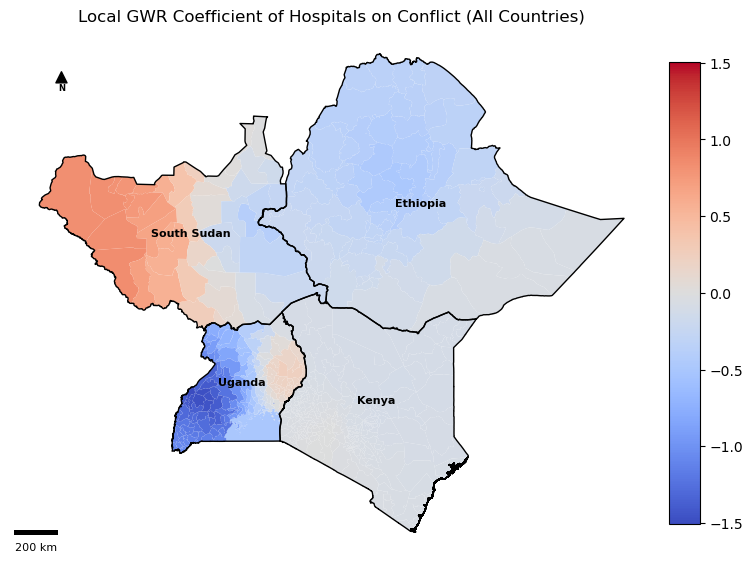

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.patches as mpatches

coef_col = "gwr_log_schools_density_coef"  # or any coefficient

# --- 2. Merge into one GeoDataFrame ---
gdf_all = pd.concat(
    [gdf_gwr_eth, gdf_gwr_ssd, gdf_gwr_ken, gdf_gwr_uga],
    ignore_index=True
)
gdf_all = gpd.GeoDataFrame(gdf_all, geometry="geometry", crs=gdf_gwr_ken.crs)

# --- 3. Compute symmetric color bounds ---
min_val = gdf_all[coef_col].min()
max_val = gdf_all[coef_col].max()
max_abs = max(abs(min_val), abs(max_val))

# --- 4. Create country outlines (only one polygon per country) ---
# We dissolve by 'country' to merge all admin units per country
country_outlines = gdf_all.dissolve(by="COUNTRY", as_index=False)

# --- 5. Plot the coefficient map ---
fig, ax = plt.subplots(figsize=(10, 12))

gdf_all.plot(
    column=coef_col,
    cmap="coolwarm",
    vmin=-max_abs,
    vmax=max_abs,
    legend=True,
    ax=ax,
    legend_kwds={
        'shrink': 0.5,  # Makes colorbar 50% of default size
        'aspect': 15,   # Makes it thinner (higher = thinner)
        'pad': 0.02#,    # Distance from plot
       # 'label': ''     # Optional: remove or customize label
    }    
)
ax.set_title("Local GWR Coefficient of Hospitals on Conflict (All Countries)")
ax.set_axis_off()

# --- 6. Overlay country borders (thicker line) ---
country_outlines.boundary.plot(ax=ax, linewidth=1, edgecolor="black")

# --- 7. Add country labels at centroid ---
for _, row in country_outlines.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x,
        centroid.y,
        row["COUNTRY"],
        horizontalalignment="center",
        fontsize=8,
        fontweight="bold",
        color="black"
        #bbox=dict(facecolor="white", edgecolor="none", alpha=0.6)
    )

# --- 8. Add scale bar (ADD THIS SECTION) ---
scalebar = ScaleBar(
    dx=1,  # 1 unit in your CRS (will be meters if using metric projection)
    units="m",  # Display in kilometers
    length_fraction=0.15,  # Shorter bar (15% of plot width)
    height_fraction=0.01,  # Thinner bar (1% of plot height)
    location='lower left',
    box_alpha=0,  # Transparent background
    font_properties={'size': 8}  # Smaller font
)
ax.add_artist(scalebar)

# --- 9. Add north arrow ---
# Get the plot limits to position the arrow
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

# Position in upper right (adjust these values as needed)
arrow_x = x_min + (x_max - x_min) * 0.08  # 8% from right edge
arrow_y = y_max - (y_max - y_min) * 0.08  # 8% from top edge
arrow_length = (y_max - y_min) * 0.04  # Arrow length as 4% of plot height

# Draw the arrow
ax.annotate('N', xy=(arrow_x, arrow_y), xytext=(arrow_x, arrow_y - arrow_length),
            arrowprops=dict(facecolor='black', width=3, headwidth=8, headlength=8),
            ha='center', va='bottom', fontsize=6, fontweight='bold')

plt.show()


In [5]:
gdf_gwr_ken.columns

Index(['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2',
       'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2',
       'geometry', 'conflict_count', 'police_count', 'population', 'area_km2',
       'conflict_rate_per_100k', 'police_per_10k', 'log_conflict_rate',
       'log_police_density', 'gwr_intercept', 'gwr_log_police_density_coef',
       'gwr_gwr_pred', 'gwr_gwr_resid', 'gwr_local_R2'],
      dtype='object')

<Figure size 800x600 with 0 Axes>

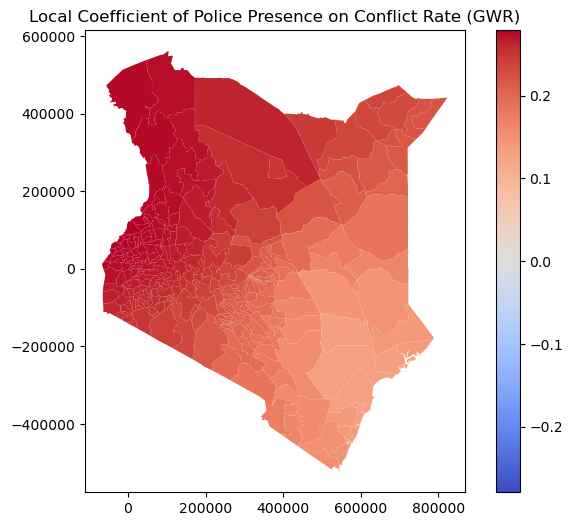

In [6]:
plt.figure(figsize=(8, 6))

# Calculate symmetric bounds around 0
max_abs_value = max(abs(gdf_gwr_ken['gwr_log_police_density_coef'].min()), 
                    abs(gdf_gwr_ken['gwr_log_police_density_coef'].max()))

gdf_gwr_ken.plot(column='gwr_log_police_density_coef',
             legend=True,
             cmap='coolwarm',
             figsize=(8,6),
             vmin=-max_abs_value,
             vmax=max_abs_value)
plt.title('Local Coefficient of Police Presence on Conflict Rate (GWR)')
plt.show()


<Figure size 800x600 with 0 Axes>

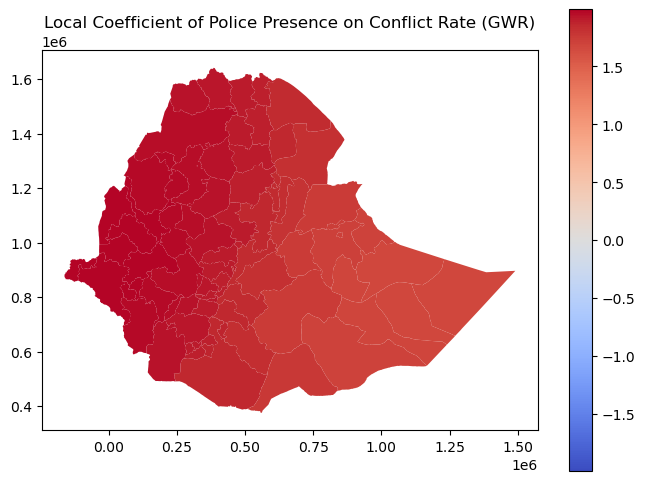

In [7]:
plt.figure(figsize=(8, 6))

# Calculate symmetric bounds around 0
max_abs_value = max(abs(gdf_gwr_eth['gwr_log_police_density_coef'].min()), 
                    abs(gdf_gwr_eth['gwr_log_police_density_coef'].max()))

gdf_gwr_eth.plot(column='gwr_log_police_density_coef',
             legend=True,
             cmap='coolwarm',
             figsize=(8,6),
             vmin=-max_abs_value,
             vmax=max_abs_value)
plt.title('Local Coefficient of Police Presence on Conflict Rate (GWR)')
plt.show()

In [5]:
plt.figure(figsize=(8, 6))
gdf_gwr.plot(column='gwr_local_R2',
             legend=True,
             cmap='viridis',
             figsize=(8,6))
plt.title('Local R² of GWR Model')
plt.show()


NameError: name 'gdf_gwr' is not defined

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

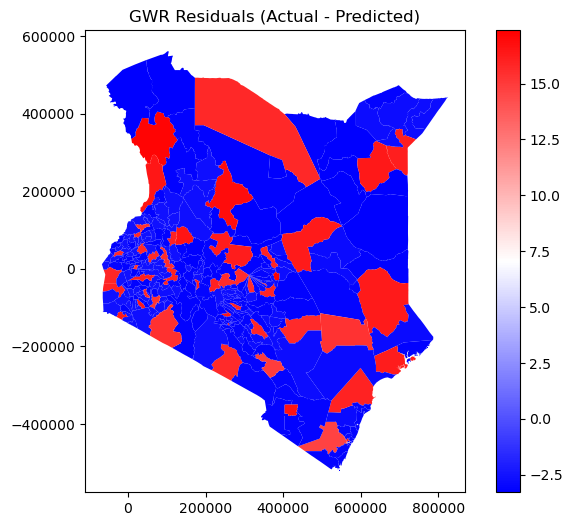

In [10]:
plt.figure(figsize=(8, 6))
gdf_gwr.plot(column='gwr_gwr_resid',
             legend=True,
             cmap='bwr',
             figsize=(8,6))
plt.title('GWR Residuals (Actual - Predicted)')
plt.show()


In [11]:
import numpy as np
import statsmodels.api as sm

# 1. Extract variables
y = gdf["log_conflict_rate"]  # dependent variable
X = gdf[["log_police_density"]]  # independent variable

# 2. Add constant
X_const = sm.add_constant(X)

# 3. Fit OLS
ols_model = sm.OLS(y, X_const).fit()

# 4. Extract OLS AIC (statsmodels gives AIC, not AICc)
ols_aic = ols_model.aic
n = len(y)
k = len(ols_model.params)  # number of parameters (including intercept)

# 5. Compute AICc manually
ols_aicc = ols_aic + (2 * k * (k + 1)) / (n - k - 1)

print(f"OLS AIC:  {ols_aic:.3f}")
print(f"OLS AICc: {ols_aicc:.3f}")


OLS AIC:  2013.221
OLS AICc: 2013.262


In [12]:
gwr_aicc = gwr_results.aicc
print(f"GWR AICc: {gwr_aicc:.3f}")


GWR AICc: 2015.317


In [13]:
print(f"OLS AICc: {ols_aicc:.3f}")
print(f"GWR AICc: {gwr_aicc:.3f}")
print(f"Difference: {ols_aicc - gwr_aicc:.3f}")


OLS AICc: 2013.262
GWR AICc: 2015.317
Difference: -2.055
